In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import torch
from model.pytorch.dcrnn_model import DCRNNModel  # Adjust based on your repo structure
from lib.utils import load_graph_data  # If needed for adjacency matrix
import yaml
import os

from lib.utils import load_graph_data
from model.pytorch.dcrnn_supervisor import DCRNNSupervisor

2025-03-04 20:48:00.443148: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-04 20:48:00.444456: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-04 20:48:00.469582: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-04 20:48:00.843923: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
def run_dcrnn(args):
    with open(args.config_filename) as f:
        supervisor_config = yaml.load(f, Loader=yaml.FullLoader)

        graph_pkl_filename = supervisor_config['data'].get('graph_pkl_filename')
        sensor_ids, sensor_id_to_ind, adj_mx = load_graph_data(graph_pkl_filename)

        supervisor = DCRNNSupervisor(adj_mx=adj_mx, **supervisor_config)
        supervisor.train()
        mean_score, outputs = supervisor.evaluate('train')
        np.savez_compressed(args.output_filename, **outputs)
        print("MAE : {}".format(mean_score))
        print('Predictions saved as {}.'.format(args.output_filename))


# if __name__ == '__main__':
#     sys.path.append(os.getcwd())
#     parser = argparse.ArgumentParser()
#     parser.add_argument('--use_cpu_only', default=False, type=str, help='Whether to run tensorflow on cpu.')
#     parser.add_argument('--config_filename', default='data/model/pretrained/METR-LA/config.yaml', type=str,
#                         help='Config file for pretrained model.')
#     parser.add_argument('--output_filename', default='data/dcrnn_predictions.npz')
#     args = parser.parse_args()
#     run_dcrnn(args)
        
def train_and_predict():

    # Load the saved predictions
    data = np.load("data/dcrnn_predictions.npz")

    # Check what keys are available in the saved file
    print("Available keys:", data.files)

    # Access specific arrays
    for key in data.files:
        print(f"{key}: shape {data[key].shape}")

    # Extract predictions and ground truth
    predictions = data['prediction']  # (12, 192, 92)
    truth = data['truth']  # (12, 192, 92)

    # Choose a sensor index (e.g., sensor 0)
    sensor_idx = 5

    # Choose a sample index (e.g., sample 0)
    sample_idx = 0

    # Extract time series
    predicted_values = predictions[sample_idx, :, sensor_idx] # (192,)
    truth_values = truth[sample_idx, :, sensor_idx] # (192,)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(truth_values, label="Ground Truth", linestyle='dashed', color='blue')
    plt.plot(predicted_values, label="Prediction", linestyle='solid', color='red')
    plt.xlabel("Time Step")
    plt.ylabel("PM2.5 Level")
    plt.title(f"Predicted vs. Ground Truth PM2.5 for Sensor {sensor_idx}")
    plt.legend()
    plt.show()

    # Select a single test sample (e.g., index 0) and sensor (e.g., index 0)
    sample_idx = 5  # Change this to see other test samples
    sensor_idx = 0  # Change this to see other sensors

    plt.plot(data["truth"][:, sample_idx, sensor_idx], label="Ground Truth", marker='o')
    plt.plot(data["prediction"][:, sample_idx, sensor_idx], label="Prediction", marker='x')

    plt.xlabel("Prediction Horizon (t+1 to t+24)")
    plt.ylabel("PM2.5 Level")
    plt.title(f"PM2.5 Prediction vs. Ground Truth for Sensor {sensor_idx}")
    plt.legend()
    plt.show()


Available keys: ['prediction', 'truth']
prediction: shape (24, 192, 92)
truth: shape (24, 192, 92)


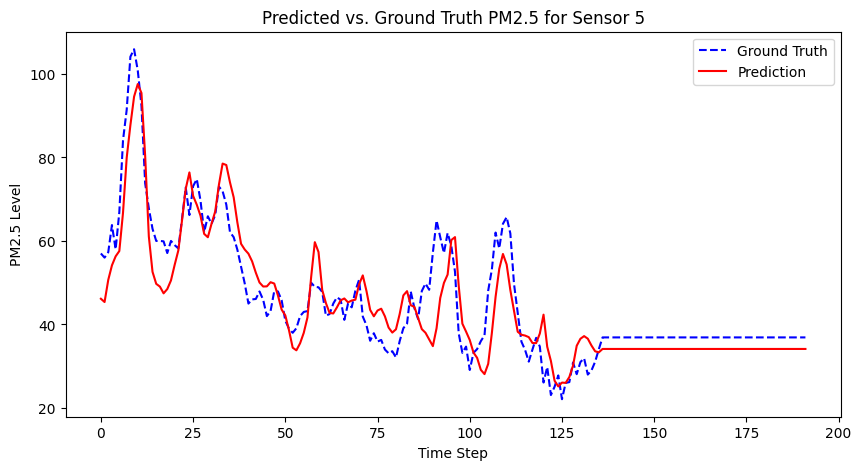

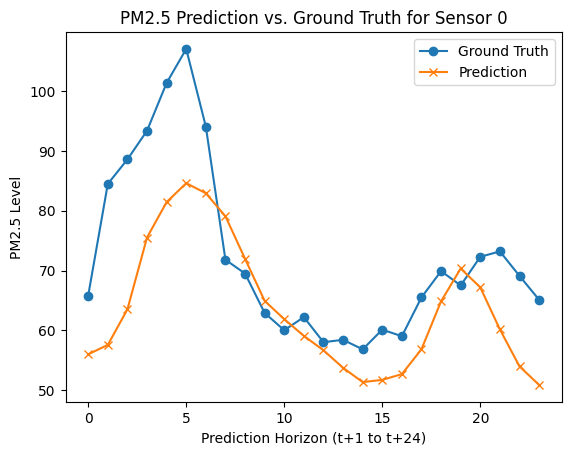

In [5]:
train_and_predict()

In [104]:
import numpy as np

data = np.load("data/data_folder/train.npz")
x_train = data['x']  # Should be (num_samples, seq_len, num_nodes, input_dim)
y_train = data['y']  # Should be (num_samples, horizon, num_nodes, output_dim)

print(f"x_train shape: {x_train.shape}")  # Expecting (N, 12, 92, 2)
print(f"y_train shape: {y_train.shape}")  # Expecting (N, 12, 92, 1)


x_train shape: (481, 24, 92, 2)
y_train shape: (481, 24, 92, 2)


In [20]:
y_train[0,0,0,:]

array([53.5       ,  0.54166667])

In [52]:
df = pd.read_hdf("data/processed_data.h5")
df

,02t,03t,11t,12t,50t,52t,53t,54t,59t,61t,...,bkp85t,19t,o63,bkp90t,bkp88t,bkp86t,bkp94t,bkp84t,bkp83t,bkp63t
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-19 01:00:00,55.5,51.7,47.1,44.2,50.1,54.5,49.9,44.9,36.9,41.1,...,62.1,55.7,54.1,50.1,66.9,65.2,48.2,52.7,51.0,49.6
2025-01-19 02:00:00,60.3,56.6,48.1,48.1,54.0,60.7,55.5,55.1,37.4,47.4,...,63.8,45.9,55.0,52.6,63.1,64.1,51.5,55.2,52.0,54.7
2025-01-19 03:00:00,57.9,58.1,46.2,45.8,55.3,56.0,56.7,46.8,40.9,44.9,...,69.8,40.5,47.3,54.4,68.0,78.9,56.4,58.8,49.0,56.9
2025-01-19 04:00:00,55.2,55.3,40.3,43.1,48.6,55.1,45.5,40.5,45.2,40.1,...,77.6,43.4,45.2,53.2,69.1,73.7,50.8,60.2,45.0,56.1
2025-01-19 05:00:00,60.7,60.3,40.9,44.5,47.9,58.4,45.1,41.4,47.2,41.1,...,92.0,50.8,53.1,70.5,72.0,74.6,49.1,76.5,41.0,48.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18 10:00:00,25.5,27.2,24.9,24.9,28.7,25.0,29.9,28.7,14.0,24.2,...,26.3,24.3,24.9,27.1,21.0,20.2,17.1,52.6,25.0,21.9
2025-02-18 11:00:00,28.1,26.7,21.1,21.9,25.4,27.5,24.2,27.3,14.9,21.0,...,27.4,23.5,22.5,19.8,28.8,16.6,17.0,22.2,18.0,29.5
2025-02-18 12:00:00,24.4,24.3,20.2,20.9,25.0,25.1,24.3,24.1,15.2,20.9,...,26.5,23.7,20.6,19.8,25.1,35.4,16.1,22.1,20.0,28.1


In [54]:
x_offsets = np.sort(
        # np.concatenate(([-week_size + 1, -day_size + 1], np.arange(-11, 1, 1)))
        np.concatenate((np.arange(-23, 1, 1),))
    )
    # Predict the next one hour
y_offsets = np.sort(np.arange(1, 25, 1))
x_offsets, y_offsets

(array([-23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11,
        -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24]))

In [78]:
def generate_graph_seq2seq_io_data(
        df, x_offsets, y_offsets, add_time_in_day=True, add_day_in_week=False, scaler=None
):
    """
    Generate samples from
    :param df:
    :param x_offsets:
    :param y_offsets:
    :param add_time_in_day:
    :param add_day_in_week:
    :param scaler:
    :return:
    # x: (epoch_size, input_length, num_nodes, input_dim)
    # y: (epoch_size, output_length, num_nodes, output_dim)
    """

    global gv

    num_samples, num_nodes = df.shape
    data = np.expand_dims(df.values, axis=-1)
    data_list = [data]
    if add_time_in_day:
        time_ind = (df.index.values - df.index.values.astype("datetime64[D]")) / np.timedelta64(1, "D")
        time_in_day = np.tile(time_ind, [1, num_nodes, 1]).transpose((2, 1, 0))
        data_list.append(time_in_day)
    if add_day_in_week:
        day_in_week = np.zeros(shape=(num_samples, num_nodes, 7))
        day_in_week[np.arange(num_samples), :, df.index.dayofweek] = 1
        data_list.append(day_in_week)

    data = np.concatenate(data_list, axis=-1)
    gv = data_list
    # epoch_len = num_samples + min(x_offsets) - max(y_offsets)
    x, y = [], []
    # t is the index of the last observation.
    min_t = abs(min(x_offsets))
    max_t = abs(num_samples - abs(max(y_offsets)))  # Exclusive
    for t in range(min_t, max_t):
        x_t = data[t + x_offsets, ...]
        y_t = data[t + y_offsets, ...]
        x.append(x_t)
        y.append(y_t)
    x = np.stack(x, axis=0)
    y = np.stack(y, axis=0)
    return x, y

In [103]:
x,y = generate_graph_seq2seq_io_data(df=df, 
                                     x_offsets=x_offsets,
                                     y_offsets=y_offsets,
                                     add_time_in_day=True,
                                     add_day_in_week=False)
x.shape, y.shape

((687, 24, 92, 2), (687, 24, 92, 2))

In [76]:
gv[:,:,0]

array([[55.5, 51.7, 47.1, ..., 52.7, 51. , 49.6],
       [60.3, 56.6, 48.1, ..., 55.2, 52. , 54.7],
       [57.9, 58.1, 46.2, ..., 58.8, 49. , 56.9],
       ...,
       [24.4, 24.3, 20.2, ..., 22.1, 20. , 28.1],
       [24.3, 24.9, 19.7, ..., 21. , 24. , 34.5],
       [27.2, 24.6, 43.6, ..., 30.2, 30. , 28.5]])

In [77]:
gv[:,:,1]

array([[0.04166667, 0.04166667, 0.04166667, ..., 0.04166667, 0.04166667,
        0.04166667],
       [0.08333333, 0.08333333, 0.08333333, ..., 0.08333333, 0.08333333,
        0.08333333],
       [0.125     , 0.125     , 0.125     , ..., 0.125     , 0.125     ,
        0.125     ],
       ...,
       [0.5       , 0.5       , 0.5       , ..., 0.5       , 0.5       ,
        0.5       ],
       [0.54166667, 0.54166667, 0.54166667, ..., 0.54166667, 0.54166667,
        0.54166667],
       [0.58333333, 0.58333333, 0.58333333, ..., 0.58333333, 0.58333333,
        0.58333333]])

In [62]:
df.shape

(734, 92)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


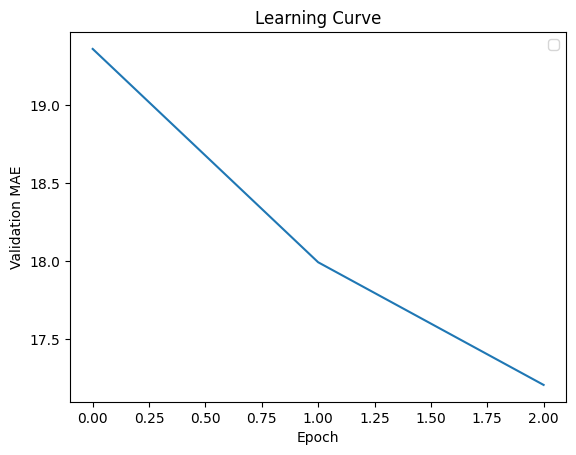

In [11]:
log_file = 'experiments/dcrnn_R_4_h_24_128-128_lr_0.001_bs_32_0304162530/info.log'

val_mae_values = []
stop_epoch = None
patience = 30

with open(log_file, 'r') as f:
    for line in f:
        if 'val_mae' in line:
            val_mae = float(line.split('val_mae: ')[1].split(',')[0])
            val_mae_values.append(val_mae)
        if 'Early stopping at epoch' in line:
            stop_epoch = int(line.split('epoch: ')[1]) - patience

plt.plot(val_mae_values)
if stop_epoch:
    plt.axvline(x=stop_epoch, color='r', linestyle='--', label='Early stopping')
plt.xlabel('Epoch')
plt.ylabel('Validation MAE')
plt.title('Learning Curve')
plt.legend()
plt.show()